# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

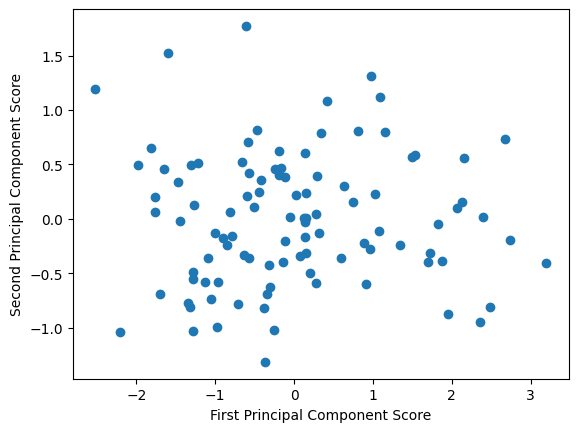

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

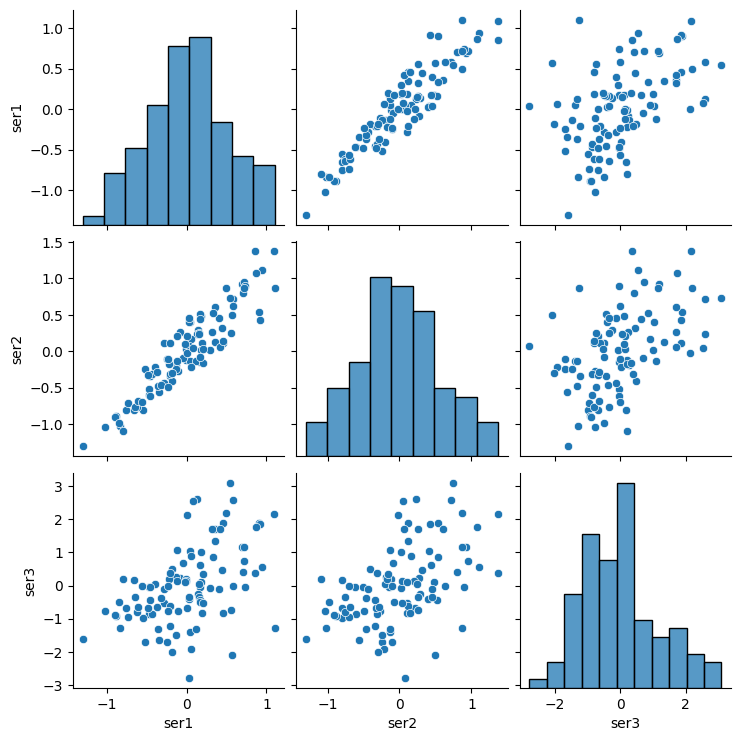

In [3]:
import seaborn as sns
sns.pairplot(df)
plt.show()

## Answer

- The three outliers in the upper left of the graph have low scores for the first principal component and high scores for the second. That means they don’t match the main pattern in the data and stand out due to some unusual values. 
- The first component mostly reflects a mix of all three series, especially since series_1 and series_2 are tightly linked. The second component likely picks up on differences in series_3, which has more noise. So, we can say these outliers probably had unusual values in series_3. But it’s hard to say much about series_1 and series_2 because they’re almost the same, just with a little bit of noise added to series_1 to get series_2. PCA can’t easily tell them apart. 
- The scatter plot is good for spotting big patterns and outliers, but it doesn’t explain which specific series caused those patterns. If you try a pairplot of all three series, you’ll see that series_1 and series_2 look nearly the same, while series_3 spreads out more and might show those outliers clearly.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

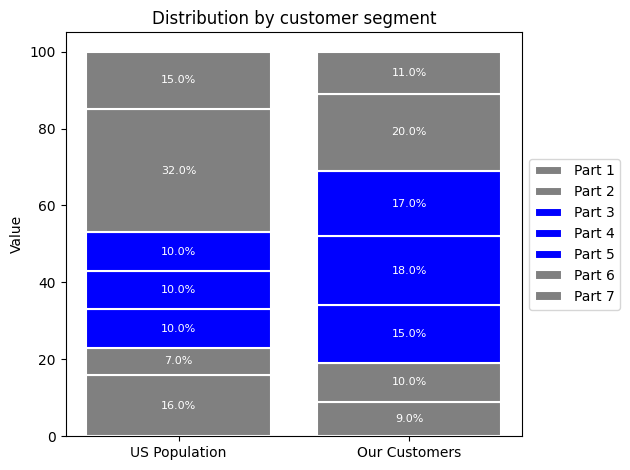

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Each list represents the 7 stacked segments for one bar
bar1_segments = [16,7,10,10,10,32,15]
bar2_segments = [9,10,15,18,17,20,11]

colors = []
for i in range(7):
    if 2 <= i <= 4:  # Parts 3, 4, 5 (middle segments)
        colors.append('Blue')  # Blue shades
    else:  # Outer segments
        colors.append('Grey')  # Grey shades

# Position of the two bars
x_pos = [0, 1]
total1 = np.sum(bar1_segments)
total2 = np.sum(bar2_segments)
# Stack the first bar
bottom = 0
for i, val in enumerate(bar1_segments):
    plt.bar(x_pos[0], val, bottom=bottom, label=f'Part {i+1}' if x_pos[0]==0 else "", color=colors[i],
            edgecolor='white', linewidth=1.5)
    percent = val / total1 * 100
    plt.text(x_pos[0], bottom + val / 2, f'{percent:.1f}%', ha='center', va='center', fontsize=8, 
             color='white')
    bottom += val

# Stack the second bar
bottom = 0
for i, val in enumerate(bar2_segments):
    plt.bar(x_pos[1], val, bottom=bottom, color=colors[i],
            edgecolor='white', linewidth=1.5)
    percent = val / total2 * 100
    plt.text(x_pos[1], bottom + val / 2, f'{percent:.1f}%', ha='center', va='center', 
             fontsize=8, color='white')
    bottom += val

plt.xticks(x_pos, ['US Population', 'Our Customers'])
plt.ylabel('Value')
plt.title('Distribution by customer segment')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()
